In [16]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import MinMaxScaler


In [19]:
df = pd.read_csv("student_performance.csv")

print("First Five Records")
print(df.head())

print("\nDataset Information")
print(df.info())

First Five Records
   Student_ID     Name  Attendance  Assignment_Score  Participation  \
0         101    Alice          95                88              9   
1         102      Bob          72                65              5   
2         103  Charlie          85                78              8   
3         104    David          60                55              4   
4         105      Eva          98                94             10   

   Exam_Score  
0          92  
1          68  
2          80  
3          58  
4          96  

Dataset Information
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20 entries, 0 to 19
Data columns (total 6 columns):
 #   Column            Non-Null Count  Dtype 
---  ------            --------------  ----- 
 0   Student_ID        20 non-null     int64 
 1   Name              20 non-null     object
 2   Attendance        20 non-null     int64 
 3   Assignment_Score  20 non-null     int64 
 4   Participation     20 non-null     int64 
 5   Exam_Sco

In [20]:

print("\nMissing Values")
print(df.isnull().sum())



Missing Values
Student_ID          0
Name                0
Attendance          0
Assignment_Score    0
Participation       0
Exam_Score          0
dtype: int64


In [21]:
print("\nChecking Duplicate Records")
print(df.duplicated().sum())


Checking Duplicate Records
0


In [22]:
df = df.drop_duplicates()

In [1]:
scaler = MinMaxScaler()

columns = ['Attendance',
           'Assignment_Score',
           'Participation',
           'Exam_Score']

df[columns] = scaler.fit_transform(df[columns])

print("\nNormalized Dataset")
print(df.head())


NameError: name 'MinMaxScaler' is not defined

In [24]:
df["Performance"] = (
      df["Attendance"]*0.20
    + df["Assignment_Score"]*0.30
    + df["Participation"]*0.10
    + df["Exam_Score"]*0.40
)

print("\nPerformance Score")
print(df[["Name","Performance"]])


Performance Score
       Name  Performance
0     Alice     0.872920
1       Bob     0.346772
2   Charlie     0.641108
3     David     0.123049
4       Eva     0.975942
5     Frank     0.522697
6     Grace     0.242660
7     Henry     0.794882
8       Ivy     0.465169
9      Jack     0.000000
10     Kate     0.733902
11      Leo     0.856938
12      Mia     0.340078
13     Noah     0.637534
14   Olivia     0.995349
15    Peter     0.169742
16    Queen     0.496501
17     Ryan     0.733889
18   Sophia     0.901009
19      Tom     0.068736


In [25]:
def classify(score):

    if score >= 0.80:
        return "Excellent"

    elif score >=0.60:
        return "Good"

    elif score >=0.40:
        return "Average"

    else:
        return "At Risk"

df["Category"] = df["Performance"].apply(classify)

print("\nStudent Categories")
print(df[["Name","Category"]])



Student Categories
       Name   Category
0     Alice  Excellent
1       Bob    At Risk
2   Charlie       Good
3     David    At Risk
4       Eva  Excellent
5     Frank    Average
6     Grace    At Risk
7     Henry       Good
8       Ivy    Average
9      Jack    At Risk
10     Kate       Good
11      Leo  Excellent
12      Mia    At Risk
13     Noah       Good
14   Olivia  Excellent
15    Peter    At Risk
16    Queen    Average
17     Ryan       Good
18   Sophia  Excellent
19      Tom    At Risk


In [26]:
risk = df[df["Category"]=="At Risk"]

print("\nAt Risk Students")
print(risk[["Student_ID","Name"]])


At Risk Students
    Student_ID   Name
1          102    Bob
3          104  David
6          107  Grace
9          110   Jack
12         113    Mia
15         116  Peter
19         120    Tom


In [27]:
print("\nSummary Statistics")
print(df.describe())



Summary Statistics
       Student_ID  Attendance  Assignment_Score  Participation  Exam_Score  \
count    20.00000   20.000000         20.000000      20.000000   20.000000   
mean    110.50000    0.567442          0.545556       0.535714    0.538043   
std       5.91608    0.318278          0.315876       0.327327    0.314388   
min     101.00000    0.000000          0.000000       0.000000    0.000000   
25%     105.75000    0.337209          0.305556       0.285714    0.282609   
50%     110.50000    0.627907          0.588889       0.571429    0.554348   
75%     115.25000    0.825581          0.794444       0.857143    0.798913   
max     120.00000    1.000000          1.000000       1.000000    1.000000   

       Performance  
count    20.000000  
mean      0.545944  
std       0.315922  
min       0.000000  
25%       0.315723  
50%       0.580116  
75%       0.810396  
max       0.995349  


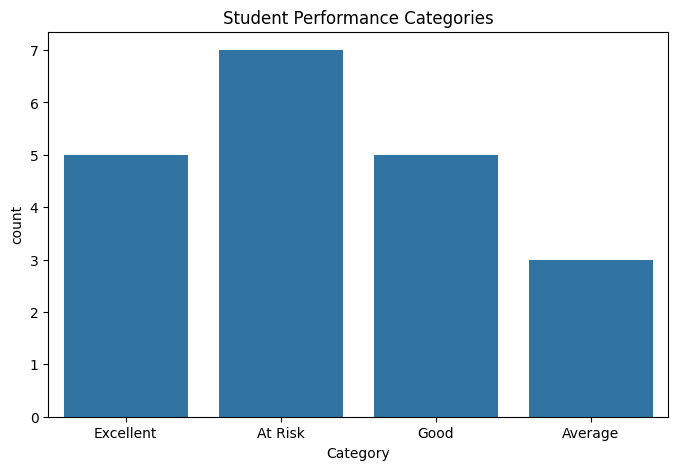

In [28]:
plt.figure(figsize=(8,5))

sns.countplot(x="Category",
              data=df)

plt.title("Student Performance Categories")

plt.show()

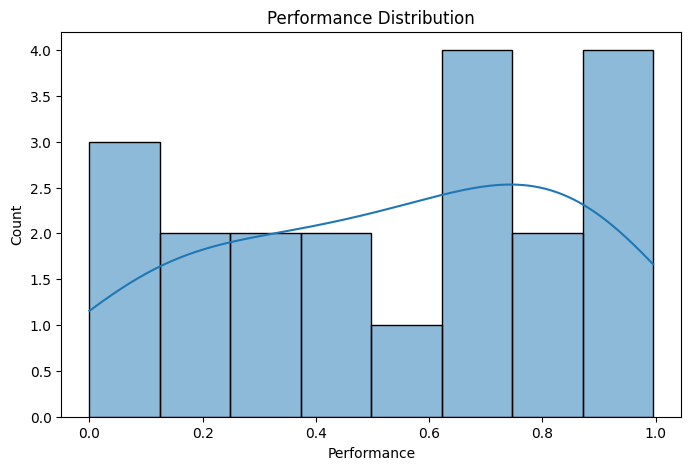

In [29]:
plt.figure(figsize=(8,5))

sns.histplot(df["Performance"],
             bins=8,
             kde=True)

plt.title("Performance Distribution")

plt.show()

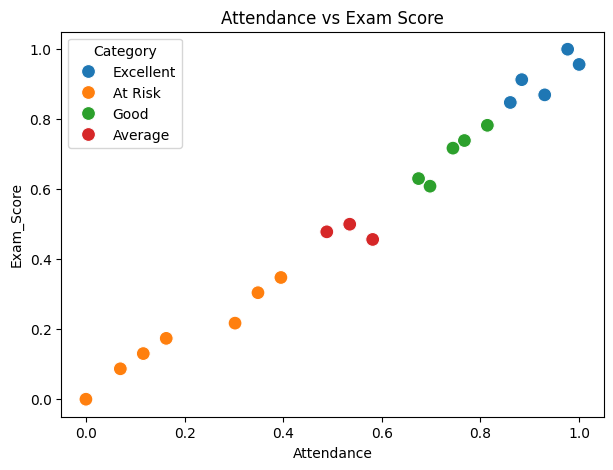

In [30]:
plt.figure(figsize=(7,5))

sns.scatterplot(x="Attendance",
                y="Exam_Score",
                hue="Category",
                data=df,
                s=100)

plt.title("Attendance vs Exam Score")

plt.show()

In [32]:
df.to_csv("Student_Performance_Report.csv",
          index=False)

print("\nReport Generated Successfully")


Report Generated Successfully
